## 1. Setup

In [4]:
!pip install nltk scikit-learn matplotlib seaborn wordcloud pandas --quiet

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)
nltk.download('words', quiet=True)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
from scipy.sparse import hstack
from wordcloud import WordCloud

plt.style.use('seaborn-v0_8-darkgrid')
print("Ready!")

ModuleNotFoundError: No module named 'wordcloud'

## 2. Dataset

Real-world style Hinglish sentences — the kind you'd see on Twitter or WhatsApp.

In [8]:
data = {
    'text': [
        # positive
        "Yaar ye movie bahut hi amazing thi, must watch hai!",
        "Aaj ka din bahut productive raha, sab kuch on time hua",
        "Bhai ye restaurant ka khana literally best hai poore city mein",
        "Finally exam clear ho gaya, bohot khush hoon aaj",
        "Job offer aa gaya bhai! Dream company se call aaya",
        "Dost log bahut caring hain, I'm so lucky to have them",
        "Aaj gym mein beast mode tha, feeling so energetic",
        "Ye naya phone ekdum zabardast hai, camera is outstanding",
        "Match mein India ne jeeta! Kya performance tha yaar",
        "Promotion mil gayi finally, saal bhar ki mehnat rang layi",
        "Weekend trip planning kar rahe hain, super excited hoon",
        "Ghar ka khana hamesha best rehta hai, nothing beats it",
        "Didi ne surprise gift diya, so thoughtful hai woh",
        "Coffee peete hue sunset dekha, best feeling ever",
        "Ye song mujhe bohot pasand hai, repeat pe sun raha hoon",

        # negative
        "Yaar aaj traffic mein 2 ghante phase raha, bahut bura laga",
        "Exam mein bahut kharab gaya, disappointed hoon khud se",
        "Bhai boss ne phir se overtime bola, this is so unfair",
        "Phone kho gaya, itna important data tha usme, devastated hoon",
        "Dosto ne plan cancel kar diya last minute pe, bahut bura laga",
        "Ye internet itna slow hai, literally pagal ho jaunga",
        "Kuch bhi sahi nahi ho raha aajkal, everything feels wrong",
        "Salary cut ho gayi, bohot tension ho rahi hai yaar",
        "Ye movie waste of time thi, poora paisa barbaad",
        "Aaj baarish mein bheeg gaya aur koi umbrella nahi tha",
        "Relationship mein bahut problems aa rahi hain recently",
        "Ghar mein lights gayi aur important meeting thi, disaster",
        "Neighbour itna shor karta hai, neend hi nahi aati",
        "Ye project bohut boring hai, kuch samajh nahi aa raha",
        "Aaj kuch bhi theek nahi laga, bahut low feel ho raha hai",

        # neutral
        "Kal meeting hai office mein, prepare karna padega",
        "Train 10 minute late aa rahi hai platform number 3 se",
        "Delhi mein aajkal temperature 35 degree ke aaspaas hai",
        "Office ka timing 9 to 6 hai, Saturday off hota hai",
        "Petrol ki price phir se badh gayi hai is hafte",
        "Ye form online fill karna padega aur documents upload karne honge",
        "Match kal raat 8 baje start hoga Star Sports pe",
        "Is app mein payment UPI se bhi ho sakta hai",
        "College ke admission ke liye merit list Monday ko aayegi",
        "Ye medicine khane ke baad hi leni hai, before sleep",
        "Ghar se airport 45 minute ka drive hai normally",
        "Is course mein 3 modules hain, har module 2 weeks ka hai",
        "Aaj market band hai isliye bahar nahi jaunga",
        "Mera address sector 15, Noida hai near metro station",
        "Ye recipe mein dahi aur mirchi dono dalne padte hain",
    ],
    'sentiment': ['positive']*15 + ['negative']*15 + ['neutral']*15
}

df = pd.DataFrame(data)
print(f"Dataset: {len(df)} sentences")
print(df['sentiment'].value_counts())
df.head(6)

Dataset: 45 sentences
sentiment
positive    15
negative    15
neutral     15
Name: count, dtype: int64


,text,sentiment
0,"Yaar ye movie bahut hi amazing thi, must watch...",positive
1,"Aaj ka din bahut productive raha, sab kuch on ...",positive
2,Bhai ye restaurant ka khana literally best hai...,positive
3,"Finally exam clear ho gaya, bohot khush hoon aaj",positive
4,Job offer aa gaya bhai! Dream company se call ...,positive
5,"Dost log bahut caring hain, I'm so lucky to ha...",positive


## 3. Preprocessing

Standard cleaning + a Hinglish-specific stopword list.

In [9]:
# combining english stopwords with common hindi function words
hindi_stops = {
    'hai', 'hain', 'tha', 'thi', 'mein', 'se', 'ka', 'ki', 'ke',
    'ko', 'par', 'pe', 'aur', 'toh', 'hi', 'bhi', 'jo', 'ye',
    'woh', 'hum', 'tum', 'aap', 'ab', 'kuch', 'koi', 'sab',
    'raha', 'rahi', 'rahe', 'gaya', 'gayi', 'aaya', 'aayi',
    'mere', 'mera', 'meri', 'iska', 'unka', 'isliye'
}
english_stops = set(stopwords.words('english'))
all_stops = hindi_stops | english_stops

def clean(text):
    text = text.lower()
    text = re.sub(r'http\S+|@\w+|#\w+', '', text)   # remove links, mentions
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)       # normalize repeats: yaarr → yaar
    text = re.sub(r'[^\w\s]', ' ', text)              # remove punctuation
    tokens = text.split()
    tokens = [t for t in tokens if t not in all_stops and len(t) > 1]
    return ' '.join(tokens)

df['clean'] = df['text'].apply(clean)

# quick before/after check
for i in [0, 15, 30]:
    print(f"Before: {df['text'][i]}")
    print(f"After:  {df['clean'][i]}\n")

Before: Yaar ye movie bahut hi amazing thi, must watch hai!
After:  yaar movie bahut amazing must watch

Before: Yaar aaj traffic mein 2 ghante phase raha, bahut bura laga
After:  yaar aaj traffic ghante phase bahut bura laga

Before: Kal meeting hai office mein, prepare karna padega
After:  kal meeting office prepare karna padega



## 4. Language Identification

Tagging each word as Hindi (HI), English (EN), or Unknown.

In [10]:
from nltk.corpus import words as nltk_words
english_vocab = set(w.lower() for w in nltk_words.words())

hindi_vocab = {
    'yaar','bhai','dost','bahut','bohot','ekdum','bilkul','achha','theek',
    'aaj','kal','kya','nahi','haan','khana','ghar','dil','kaam','din',
    'raat','log','baat','khush','dukhi','mehnat','tension','poora','thoda',
    'phir','wala','wali','rang','didi','zyada','sirf','kaafi','pagal',
    'zabardast','kharab','bura','neend','shor','paisa','salary','promotion'
}

def tag_word(word):
    w = word.lower().strip('.,!?')
    if w in hindi_vocab:
        return 'HI'
    elif w in english_vocab and len(w) > 2:
        return 'EN'
    return 'UNK'

def lang_ratio(text):
    tags = [tag_word(w) for w in text.split()]
    c = Counter(tags)
    total = len(tags) or 1
    return c['HI']/total, c['EN']/total

df[['hi_ratio', 'en_ratio']] = df['text'].apply(lambda t: pd.Series(lang_ratio(t)))

# demo on one sentence
sample = "Yaar ye movie bahut amazing thi, must watch hai!"
print(f"Sentence: {sample}\n")
for word in sample.split():
    print(f"  {word:15} → {tag_word(word)}")

Sentence: Yaar ye movie bahut amazing thi, must watch hai!

  Yaar            → HI
  ye              → UNK
  movie           → EN
  bahut           → HI
  amazing         → EN
  thi,            → UNK
  must            → EN
  watch           → EN
  hai!            → UNK


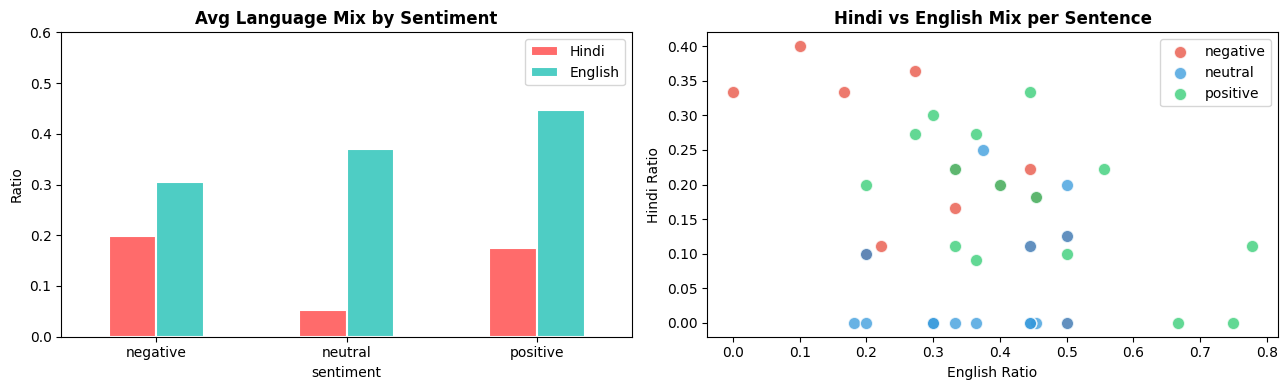

In [11]:
# how much hindi vs english per sentiment class?
lang_by_sentiment = df.groupby('sentiment')[['hi_ratio','en_ratio']].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# stacked bar — language mix per sentiment
lang_by_sentiment.plot(kind='bar', ax=axes[0], color=['#FF6B6B','#4ECDC4'],
                       edgecolor='white', linewidth=1.5, rot=0)
axes[0].set_title('Avg Language Mix by Sentiment', fontweight='bold')
axes[0].set_ylabel('Ratio')
axes[0].legend(['Hindi', 'English'])
axes[0].set_ylim(0, 0.6)

# scatter of hi vs en ratio colored by sentiment
colors = {'positive':'#2ECC71','negative':'#E74C3C','neutral':'#3498DB'}
for sent, grp in df.groupby('sentiment'):
    axes[1].scatter(grp['en_ratio'], grp['hi_ratio'], label=sent,
                    color=colors[sent], s=80, alpha=0.75, edgecolors='white')
axes[1].set_xlabel('English Ratio')
axes[1].set_ylabel('Hindi Ratio')
axes[1].set_title('Hindi vs English Mix per Sentence', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('lang_mix.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Sentiment Classification

Using TF-IDF features (word + character n-grams) with Logistic Regression and SVM.

In [12]:
le = LabelEncoder()
X = df['clean'].values
y = le.fit_transform(df['sentiment'].values)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# word n-grams — captures phrases like 'bohot achha'
tfidf_w = TfidfVectorizer(ngram_range=(1,2), max_features=1500)
# char n-grams — handles spelling variants like bahut/bohot
tfidf_c = TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5), max_features=1000)

X_tr_w = tfidf_w.fit_transform(X_train)
X_te_w = tfidf_w.transform(X_test)
X_tr_c = tfidf_c.fit_transform(X_train)
X_te_c = tfidf_c.transform(X_test)

# stack both feature sets
X_tr = hstack([X_tr_w, X_tr_c])
X_te = hstack([X_te_w, X_te_c])

print(f"Train size: {X_tr.shape}, Test size: {X_te.shape}")
print(f"Classes: {le.classes_}")

Train size: (33, 1345), Test size: (12, 1345)
Classes: ['negative' 'neutral' 'positive']


In [13]:
# train both models
models = {
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    'SVM': SVC(kernel='linear', C=1.0, probability=True, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_tr, y_train)
    preds = model.predict(X_te)
    acc = accuracy_score(y_test, preds)
    results[name] = {'acc': acc, 'preds': preds}
    print(f"{name}: {acc:.3f} accuracy")
    print(classification_report(y_test, preds, target_names=le.classes_))

Logistic Regression: 0.750 accuracy
              precision    recall  f1-score   support

    negative       0.60      0.75      0.67         4
     neutral       1.00      0.75      0.86         4
    positive       0.75      0.75      0.75         4

    accuracy                           0.75        12
   macro avg       0.78      0.75      0.76        12
weighted avg       0.78      0.75      0.76        12

SVM: 0.833 accuracy
              precision    recall  f1-score   support

    negative       0.67      1.00      0.80         4
     neutral       1.00      0.75      0.86         4
    positive       1.00      0.75      0.86         4

    accuracy                           0.83        12
   macro avg       0.89      0.83      0.84        12
weighted avg       0.89      0.83      0.84        12



## 6. Results & Visualizations

NameError: name 'WordCloud' is not defined

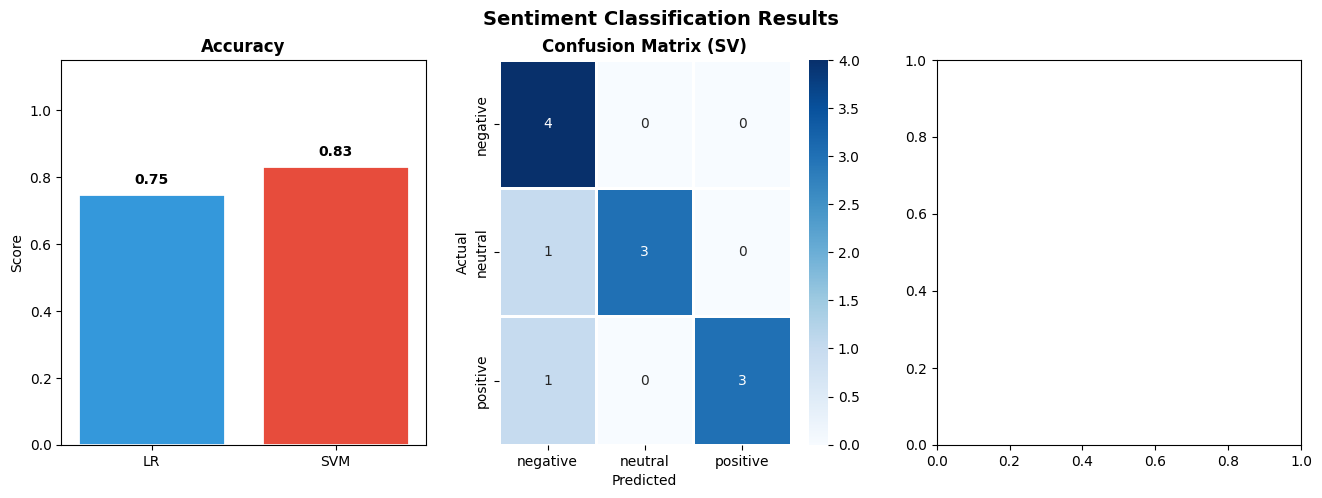

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Sentiment Classification Results', fontsize=14, fontweight='bold')

# accuracy comparison
names = list(results.keys())
accs = [results[n]['acc'] for n in names]
axes[0].bar(['LR', 'SVM'], accs, color=['#3498DB','#E74C3C'], edgecolor='white', linewidth=2)
axes[0].set_ylim(0, 1.15)
axes[0].set_title('Accuracy', fontweight='bold')
axes[0].set_ylabel('Score')
for i, acc in enumerate(accs):
    axes[0].text(i, acc + 0.03, f'{acc:.2f}', ha='center', fontweight='bold')

# confusion matrix — best model
best = max(results, key=lambda n: results[n]['acc'])
cm = confusion_matrix(y_test, results[best]['preds'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            ax=axes[1], linewidths=1, linecolor='white')
axes[1].set_title(f'Confusion Matrix ({best[:2]})', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# word cloud of full corpus
all_text = ' '.join(df['clean'].values)
wc = WordCloud(width=500, height=350, background_color='white',
               colormap='viridis', max_words=60).generate(all_text)
axes[2].imshow(wc, interpolation='bilinear')
axes[2].axis('off')
axes[2].set_title('Most Common Words', fontweight='bold')

plt.tight_layout()
plt.savefig('results.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# cross-validation for more reliable estimate (useful with small datasets)
from sklearn.model_selection import StratifiedKFold

X_full_w = tfidf_w.fit_transform(X)
X_full_c = tfidf_c.fit_transform(X)
X_full = hstack([X_full_w, X_full_c])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("5-Fold Cross-Validation:\n")
for name, model in models.items():
    scores = cross_val_score(model, X_full, y, cv=skf, scoring='accuracy')
    print(f"{name:22} mean={scores.mean():.3f}  std={scores.std():.3f}")

5-Fold Cross-Validation:

Logistic Regression    mean=0.578  std=0.130
SVM                    mean=0.511  std=0.166


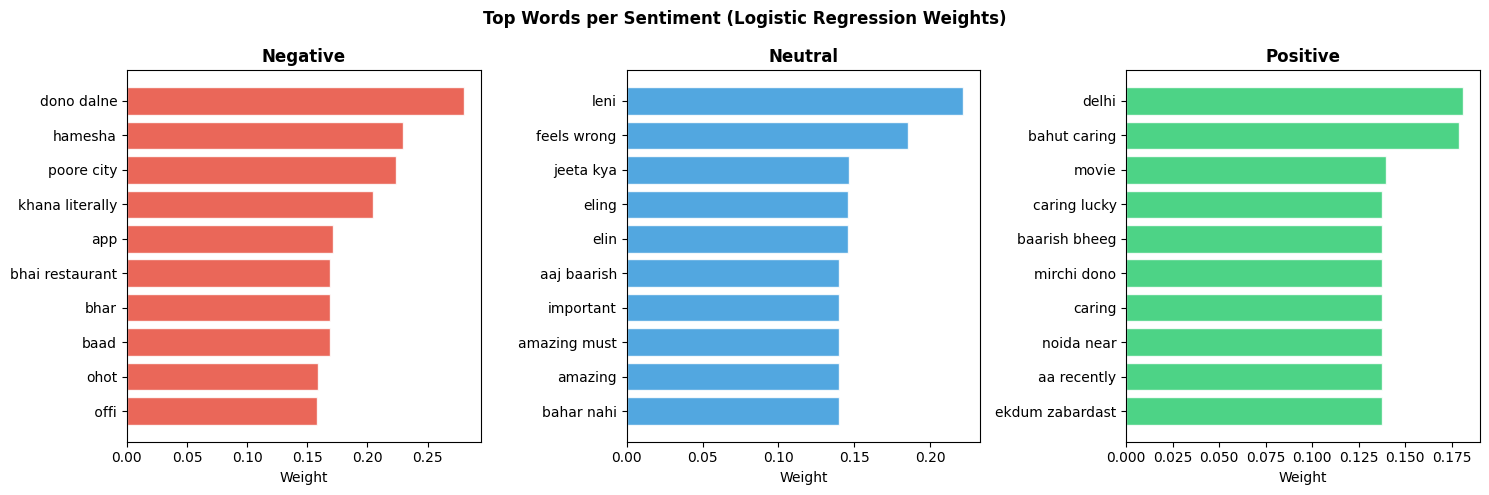

In [26]:
# top features driving each sentiment class
lr = models['Logistic Regression']

feature_names_w = tfidf_w.get_feature_names_out()
feature_names_c = tfidf_c.get_feature_names_out()
feature_names = np.concatenate([feature_names_w, feature_names_c])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Top Words per Sentiment (Logistic Regression Weights)', fontweight='bold')

palette = {'negative':'#E74C3C', 'neutral':'#3498DB', 'positive':'#2ECC71'}
for i, cls in enumerate(le.classes_):
    top_idx = lr.coef_[i].argsort()[-10:][::-1]
    top_words = [feature_names[j] for j in top_idx]
    top_vals  = [lr.coef_[i][j] for j in top_idx]
    axes[i].barh(top_words[::-1], top_vals[::-1],
                 color=palette[cls], alpha=0.85, edgecolor='white')
    axes[i].set_title(cls.capitalize(), fontweight='bold')
    axes[i].set_xlabel('Weight')

plt.tight_layout()
plt.savefig('top_features.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
def predict_hinglish(text):
    """give it any hinglish sentence, get sentiment + language stats back"""
    cleaned = clean(text)
    feat_w = tfidf_w.transform([cleaned])
    feat_c = tfidf_c.transform([cleaned])
    feat = hstack([feat_w, feat_c])

    pred = lr.predict(feat)[0]
    proba = lr.predict_proba(feat)[0]
    sentiment = le.inverse_transform([pred])[0]
    hi_r, en_r = lang_ratio(text)

    print(f"Text      : {text}")
    print(f"Sentiment : {sentiment.upper()}")
    print(f"Confidence: {max(proba):.2f}")
    print(f"Scores    : " + "  ".join([f"{le.classes_[i]}: {p:.2f}" for i, p in enumerate(proba)]))
    print(f"Lang mix  : Hindi {hi_r*100:.0f}%  English {en_r*100:.0f}%")
    print()

# test it out
predict_hinglish("Yaar exam mein bohot kharab gaya, completely failed")
predict_hinglish("Bhai Amazon mein job lag gayi, starting next Monday!")
predict_hinglish("Aaj office mein ek meeting thi, theek hi rahi")
predict_hinglish("Ye traffic aaj itna bura tha, I'm so exhausted yaar")

Text      : Yaar exam mein bohot kharab gaya, completely failed
Sentiment : POSITIVE
Confidence: 0.42
Scores    : negative: 0.38  neutral: 0.20  positive: 0.42
Lang mix  : Hindi 38%  English 38%

Text      : Bhai Amazon mein job lag gayi, starting next Monday!
Sentiment : POSITIVE
Confidence: 0.37
Scores    : negative: 0.28  neutral: 0.35  positive: 0.37
Lang mix  : Hindi 11%  English 78%

Text      : Aaj office mein ek meeting thi, theek hi rahi
Sentiment : NEUTRAL
Confidence: 0.45
Scores    : negative: 0.29  neutral: 0.45  positive: 0.26
Lang mix  : Hindi 22%  English 33%

Text      : Ye traffic aaj itna bura tha, I'm so exhausted yaar
Sentiment : NEGATIVE
Confidence: 0.56
Scores    : negative: 0.56  neutral: 0.19  positive: 0.25
Lang mix  : Hindi 30%  English 30%



In [28]:
feat_w = tfidf_w.fit_transform(X)
feat_c = tfidf_c.fit_transform(X)
feat = hstack([feat_w, feat_c])

lr.fit(feat, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

## 7. Experiment

Pass any Hinglish sentence and get a prediction.

In [29]:
# type your own sentence here!
my_sentence = "Yaar aaj bohot maza aaya, best day ever!"
predict_hinglish(my_sentence)

Text      : Yaar aaj bohot maza aaya, best day ever!
Sentiment : POSITIVE
Confidence: 0.53
Scores    : negative: 0.28  neutral: 0.19  positive: 0.53
Lang mix  : Hindi 38%  English 50%



---

## Summary

| Component | Approach |
|---|---|
| Preprocessing | Lowercase, dedup chars, remove stopwords (Hindi + English) |
| Language ID | Rule-based lexicon tagging (HI / EN / UNK) |
| Features | TF-IDF word n-grams (1-2) + char n-grams (3-5) |
| Models | Logistic Regression, SVM |
| Evaluation | Accuracy, F1, Confusion Matrix, 5-Fold CV |

**Key takeaway:** Char n-grams are important for Hinglish because the same word gets spelled many ways (*bahut / bohot / bhot*). Combining word and char features gives a nice boost.

*Built with Python + scikit-learn ☕*